In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"/Users/siddhu/Desktop/Programs/Machine Learning/Ex7/FlavorSense.csv")
print(df.head())

    age sleep_cycle exercise_habits climate_zone historical_cuisine_exposure  \
0  56.0   Irregular           Heavy    Temperate                         NaN   
1   NaN   Night Owl           Heavy    Temperate                       Asian   
2  46.0   Night Owl           Heavy         Cold                       Mixed   
3  32.0  Early Bird           Heavy         Cold               Mediterranean   
4  60.0   Night Owl        Moderate          Dry               Mediterranean   

  preferred_taste  
0           Salty  
1           Sweet  
2            Sour  
3           Salty  
4            Sour  


In [3]:
print(df.isnull().sum())

age                            968
sleep_cycle                    684
exercise_habits                804
climate_zone                   533
historical_cuisine_exposure    654
preferred_taste                  0
dtype: int64


In [4]:
df['age'].fillna(df['age'].median(), inplace=True)

categorical_cols = ['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/var/folders/vt/y6d48g2s7cg7csds0384wh400000gn/T/ipykernel_22830/3553590000.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/var/folders/vt/y6d48g2s7cg7csds0384wh400000gn/T/ipykernel_22830/3553590000.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [5]:
print(df.isnull().sum())

age                            0
sleep_cycle                    0
exercise_habits                0
climate_zone                   0
historical_cuisine_exposure    0
preferred_taste                0
dtype: int64


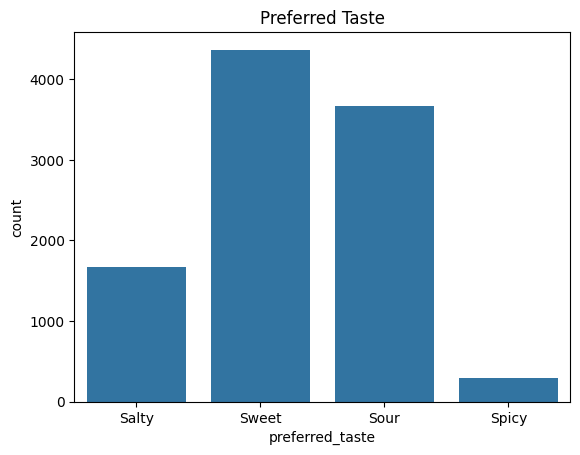

In [6]:
df['preferred_taste'].value_counts()
df['preferred_taste'].value_counts(normalize=True) * 100
sns.countplot(x='preferred_taste', data=df)
plt.title('Preferred Taste')
plt.show()

Number of outiers in 'age' : 0
Empty DataFrame
Columns: [age]
Index: []


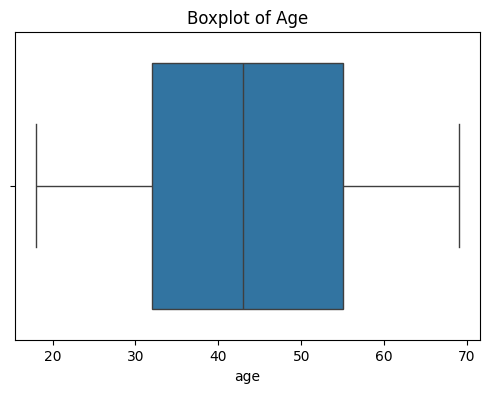

In [7]:
z_scores = stats.zscore(df['age'])
outliers = df[np.abs(z_scores)>3]
print("Number of outiers in 'age' :",outliers.shape[0])
print(outliers[['age']])

plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

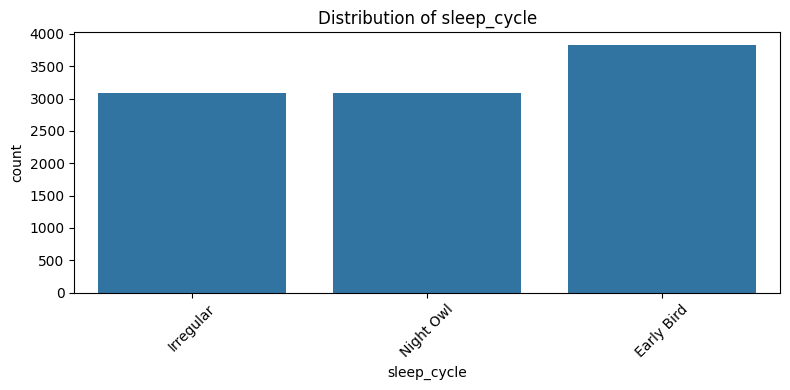

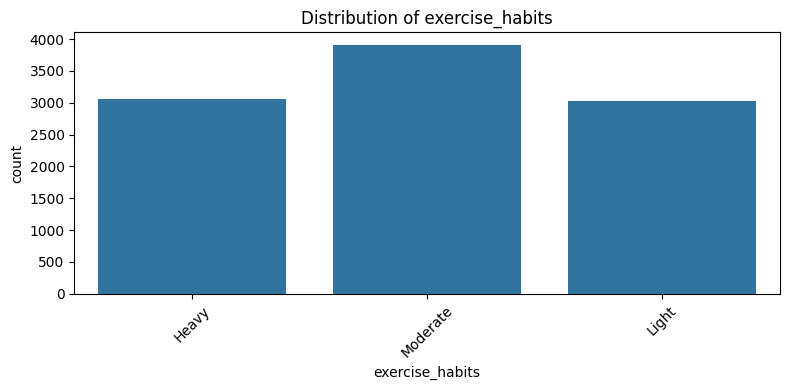

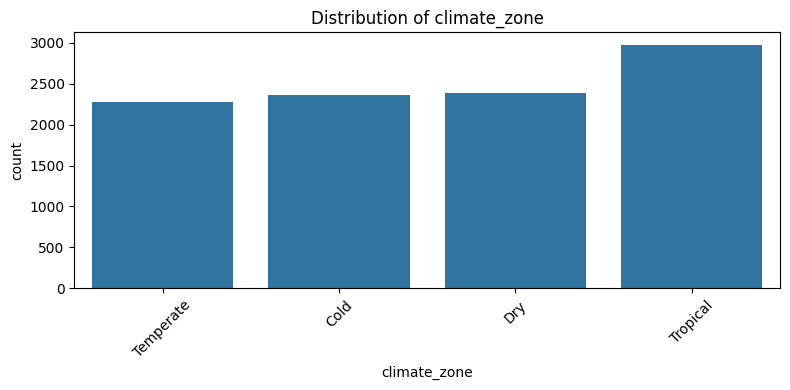

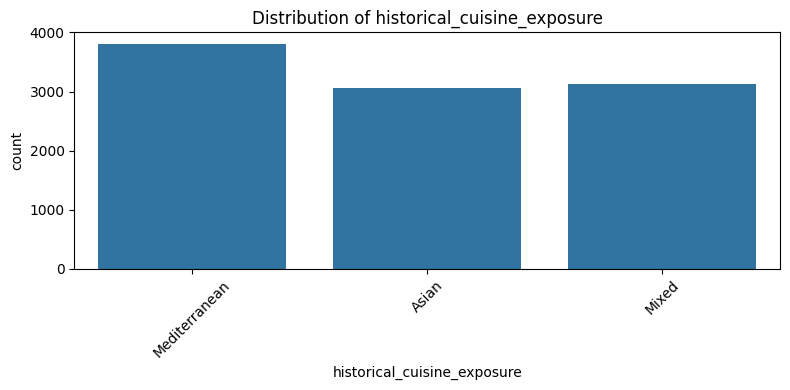

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Safely drop the 'age' column if it exists
if 'age' in df.columns:
    df = df.drop('age', axis=1)

# Loop through columns (excluding the last column)
for col in df.columns[:-1]:
    plt.figure(figsize=(8, 4))

    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col, kde=True, bins=20, color='skyblue')
        if np.issubdtype(df[col].dtype, np.number):
            plt.xticks(ticks=np.arange(int(df[col].min()), int(df[col].max())+1, step=1))

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


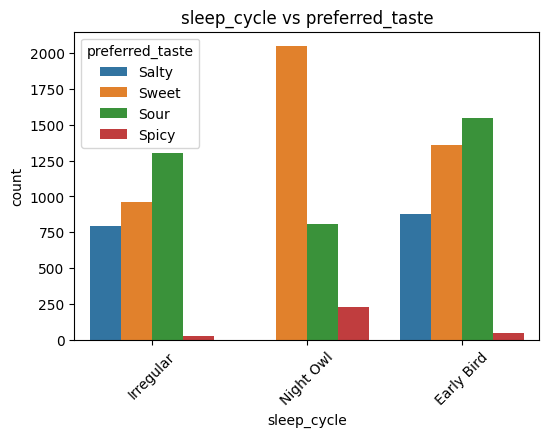

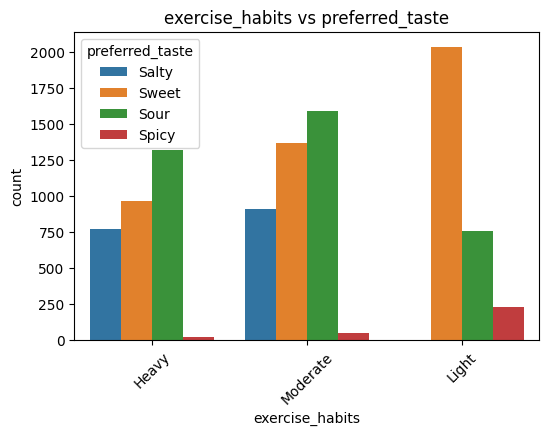

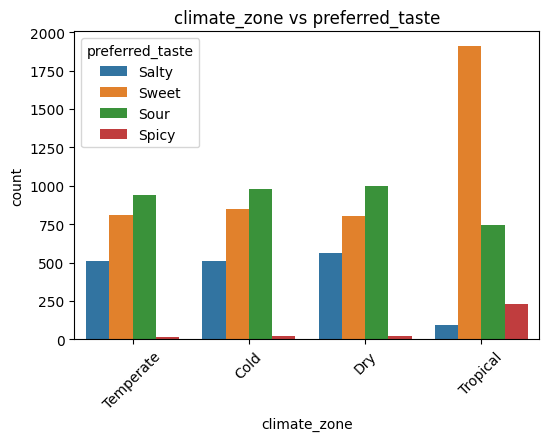

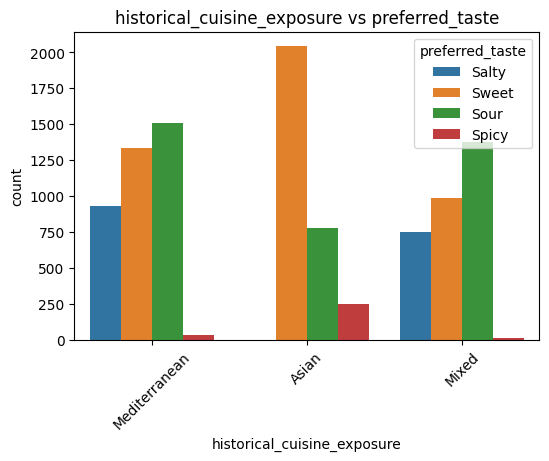

In [9]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col, hue='preferred_taste')
    else:
        sns.boxplot(data=df, x='preferred_taste', y=col)
    plt.title(f"{col} vs preferred_taste")
    plt.xticks(rotation=45)
    plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.columns:
    if df_encoded[col].dtype =='object':
        le = LabelEncoder()
        df_encoded[col]= le.fit_transform(df_encoded[col])
        label_encoders[col]=le

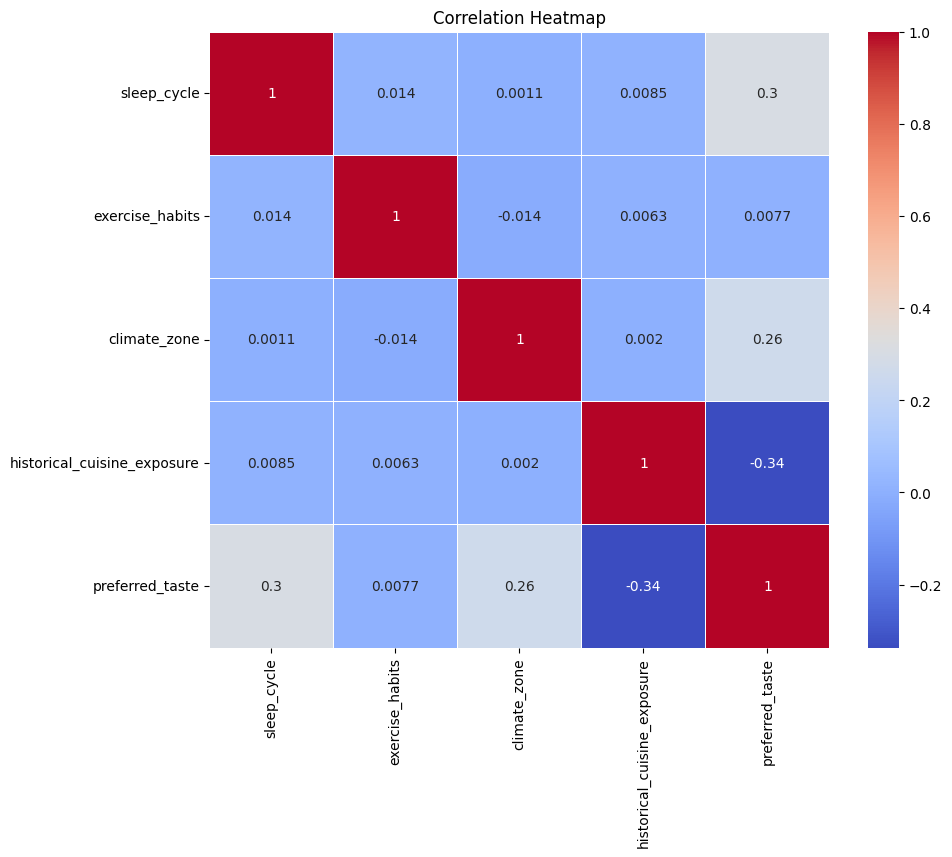

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),annot = True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = df_encoded.drop('preferred_taste',axis=1)
y=df_encoded['preferred_taste']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state =42)

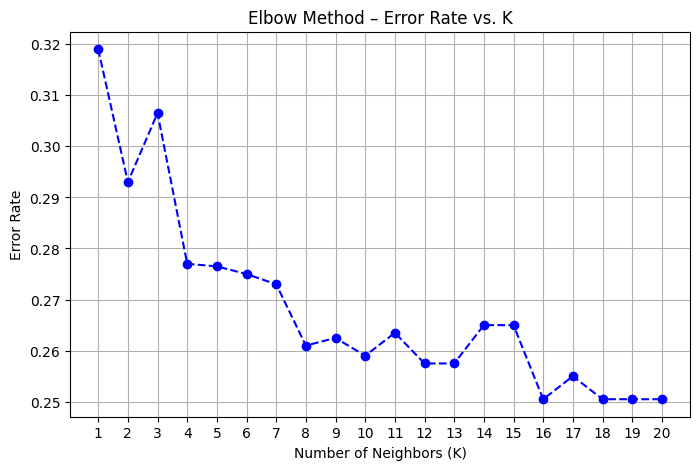

In [14]:
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred_k)
    error_rates.append(error)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, marker='o', linestyle='--', color='b')
plt.title("Elbow Method – Error Rate vs. K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [15]:
optimal_k = 11  

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


Accuracy: 0.7365

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.87      0.76       339
           1       0.68      0.72      0.70       741
           2       0.94      0.23      0.37        65
           3       0.83      0.74      0.78       855

    accuracy                           0.74      2000
   macro avg       0.78      0.64      0.65      2000
weighted avg       0.75      0.74      0.73      2000



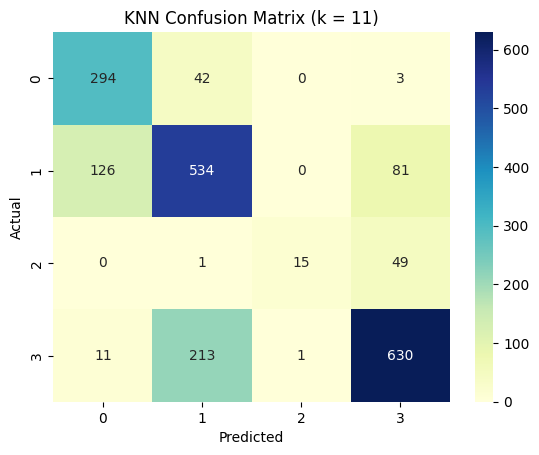

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f"KNN Confusion Matrix (k = {optimal_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
